In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

## Implement 3D spectral decomposition


3D SPECTRAL DECOMPOSITION
3x3 Matrix A:
[[4 1 2]
 [1 3 1]
 [2 1 5]]

Eigenvalues:
[7.04891734 2.30797853 2.64310413]

Eigenvectors (columns):
[[ 0.59100905  0.73697623 -0.32798528]
 [ 0.32798528 -0.59100905 -0.73697623]
 [ 0.73697623 -0.32798528  0.59100905]]

Reconstruction Error: 8.30e-15


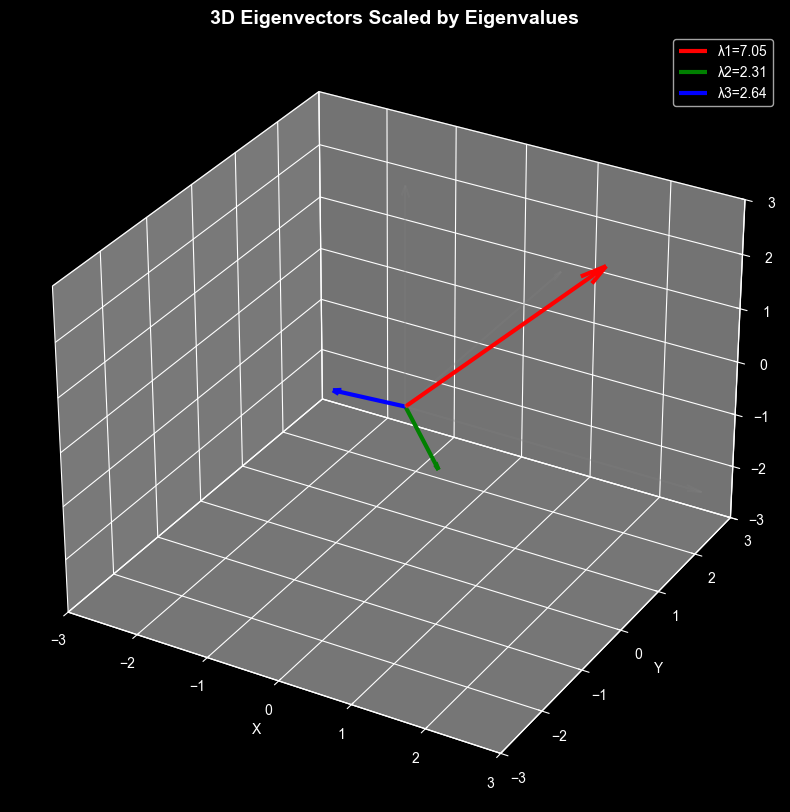

Saved to: task4_spectral_decomposition_3d.png


In [2]:
def spectral_decomposition(a):
    # Compute eigenvalues and eigenvectors
    eigen_values, eigen_vectors = np.linalg.eig(a)

    # Construct diagonal matrix of eigenvalues
    lambda_mat = np.diag(eigen_values)

    # Reconstruct matrix: A = Q * Lambda_mat * Q^(-1)
    q = eigen_vectors
    q_inv = np.linalg.inv(q)
    mat_reconstructed = q @ lambda_mat @ q_inv

    return eigen_values, eigen_vectors, mat_reconstructed

A_3x3 = np.array([[4, 1, 2],
                  [1, 3, 1],
                  [2, 1, 5]])

print("\n" + "=" * 60)
print("3D SPECTRAL DECOMPOSITION")
print("=" * 60)
print(f"3x3 Matrix A:\n{A_3x3}\n")

eigenvalues_3d, eigenvectors_3d, A_reconstructed_3d = spectral_decomposition(A_3x3)

print(f"Eigenvalues:\n{eigenvalues_3d}\n")
print(f"Eigenvectors (columns):\n{eigenvectors_3d}\n")
print(f"Reconstruction Error: {np.linalg.norm(A_3x3 - A_reconstructed_3d):.2e}")

# 3D Visualization
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot eigenvectors as arrows
colors_3d = ['red', 'green', 'blue']
for i in range(3):
    vec = eigenvectors_3d[:, i]
    val = eigenvalues_3d[i]
    # Scale for visibility
    scale = abs(val) * 0.5
    ax.quiver(0, 0, 0, vec[0]*scale, vec[1]*scale, vec[2]*scale,
              color=colors_3d[i], arrow_length_ratio=0.1, linewidth=3,
              label=f'λ{i+1}={val:.2f}')

# Add coordinate axes
ax.quiver(0, 0, 0, 4, 0, 0, color='gray', arrow_length_ratio=0.05, alpha=0.3)
ax.quiver(0, 0, 0, 0, 4, 0, color='gray', arrow_length_ratio=0.05, alpha=0.3)
ax.quiver(0, 0, 0, 0, 0, 4, color='gray', arrow_length_ratio=0.05, alpha=0.3)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D Eigenvectors Scaled by Eigenvalues', fontsize=14, fontweight='bold')
ax.legend()
ax.set_xlim([-3, 3])
ax.set_ylim([-3, 3])
ax.set_zlim([-3, 3])

output_dir = Path.cwd() / "outputs"
output_dir.mkdir(parents=True, exist_ok=True)

output_file = output_dir / "task4_spectral_decomposition_3d.png"
plt.savefig(output_file, dpi=150, bbox_inches='tight')
plt.show()

print("Saved to: task4_spectral_decomposition_3d.png")